In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
np.random.seed(42)

n = 1000

data = {
    "Age": np.random.randint(18, 70, n),
    "Tenure": np.random.randint(1, 73, n),
    "MonthlyCharges": np.random.uniform(20, 120, n),
    "SupportCalls": np.random.randint(0, 10, n),
    "ContractLength": np.random.choice([1, 12, 24], n),
    "OnlineSecurity": np.random.choice([0, 1], n),
    "TechSupport": np.random.choice([0, 1], n)
}

df = pd.DataFrame(data)

# Create churn based on customer behavior
churn_score = (
    0.04 * df["SupportCalls"]
    + 0.015 * df["MonthlyCharges"]
    - 0.025 * df["Tenure"]
    - 0.03 * df["ContractLength"]
    - 0.8 * df["OnlineSecurity"]
    - 0.7 * df["TechSupport"]
)

probability = 1 / (1 + np.exp(-churn_score))

df["Churn"] = (probability > 0.5).astype(int)

print("Dataset created successfully!")
print(df.head())

Dataset created successfully!
   Age  Tenure  MonthlyCharges  SupportCalls  ContractLength  OnlineSecurity  \
0   56      15       67.669548             0              12               1   
1   69      64       59.436532             0              12               1   
2   46      28       74.941424             0              12               0   
3   32      39       94.687572             7              24               0   
4   60      57       91.549091             2               1               0   

   TechSupport  Churn  
0            0      0  
1            0      0  
2            0      1  
3            1      0  
4            0      0  


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nChurn Distribution:")
print(df["Churn"].value_counts())

Dataset Shape: (1000, 8)

Column Names:
Index(['Age', 'Tenure', 'MonthlyCharges', 'SupportCalls', 'ContractLength',
       'OnlineSecurity', 'TechSupport', 'Churn'],
      dtype='object')

Missing Values:
Age               0
Tenure            0
MonthlyCharges    0
SupportCalls      0
ContractLength    0
OnlineSecurity    0
TechSupport       0
Churn             0
dtype: int64

Churn Distribution:
Churn
0    816
1    184
Name: count, dtype: int64


In [8]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Input Features:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Input Features:
   Age  Tenure  MonthlyCharges  SupportCalls  ContractLength  OnlineSecurity  \
0   56      15       67.669548             0              12               1   
1   69      64       59.436532             0              12               1   
2   46      28       74.941424             0              12               0   
3   32      39       94.687572             7              24               0   
4   60      57       91.549091             2               1               0   

   TechSupport  
0            0  
1            0  
2            0  
3            1  
4            0  

Target Variable:
0    0
1    0
2    1
3    0
4    0
Name: Churn, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 7)
Testing Data: (200, 7)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 7)
Testing Data: (200, 7)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [14]:
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nFirst 20 Predictions:")
print(y_pred[:20])

Predictions generated successfully!

First 20 Predictions:
[0 0 1 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0]


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.975
Accuracy Percentage: 97.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       163
           1       1.00      0.86      0.93        37

    accuracy                           0.97       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.98      0.97      0.97       200



In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Customer Churn Prediction")
print("-------------------------")

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Customer Churn Prediction
-------------------------
Accuracy: 0.975
Accuracy Percentage: 97.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       163
           1       1.00      0.86      0.93        37

    accuracy                           0.97       200
   macro avg       0.99      0.93      0.96       200
weighted avg       0.98      0.97      0.97       200



Confusion Matrix:
[[163   0]
 [  5  32]]


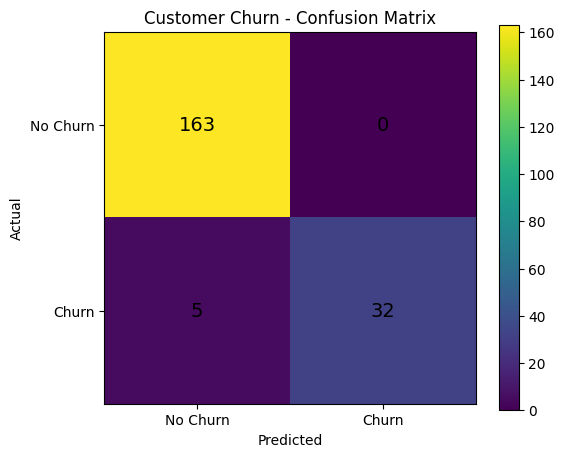

In [17]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Customer Churn - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["No Churn", "Churn"])
plt.yticks([0, 1], ["No Churn", "Churn"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 fontsize=14)

plt.colorbar()
plt.show()

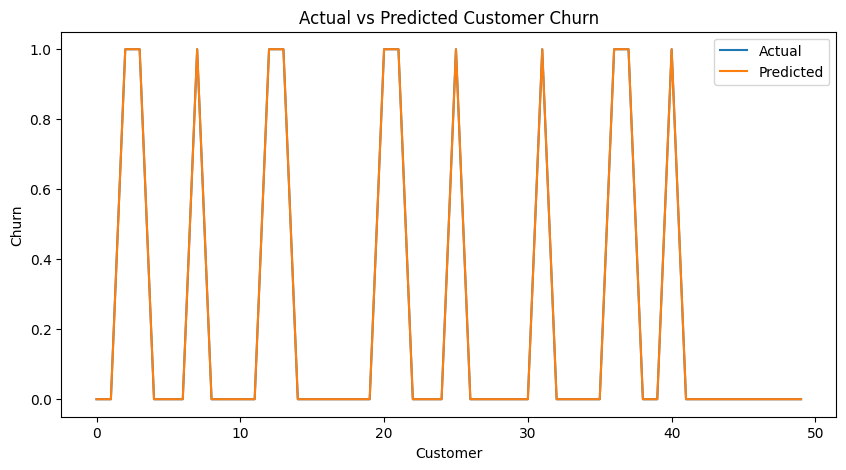

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")

plt.title("Actual vs Predicted Customer Churn")
plt.xlabel("Customer")
plt.ylabel("Churn")

plt.legend()
plt.show()

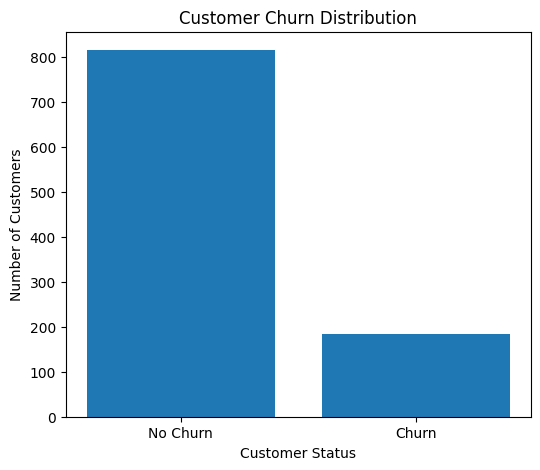

In [19]:
churn_counts = df["Churn"].value_counts()

plt.figure(figsize=(6, 5))

plt.bar(
    ["No Churn", "Churn"],
    [churn_counts.get(0, 0), churn_counts.get(1, 0)]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
# New customer details
new_customer = pd.DataFrame({
    "Age": [25],
    "Tenure": [5],
    "MonthlyCharges": [95],
    "SupportCalls": [6],
    "ContractLength": [1],
    "OnlineSecurity": [0],
    "TechSupport": [0]
})

# Scale the new customer
new_customer_scaled = scaler.transform(new_customer)

# Prediction
prediction = model.predict(new_customer_scaled)

# Probability
probability = model.predict_proba(new_customer_scaled)

print("Customer Churn Prediction")
print("-------------------------")

if prediction[0] == 1:
    print("Prediction: Customer is likely to CHURN")
else:
    print("Prediction: Customer is likely to STAY")

print("Churn Probability:",
      round(probability[0][1] * 100, 2), "%")

Customer Churn Prediction
-------------------------
Prediction: Customer is likely to CHURN
Churn Probability: 100.0 %


In [21]:
print("Complete Customer Dataset:")
display(df.head(10))

Complete Customer Dataset:


,Age,Tenure,MonthlyCharges,SupportCalls,ContractLength,OnlineSecurity,TechSupport,Churn
0,56,15,67.669548,0,12,1,0,0
1,69,64,59.436532,0,12,1,0,0
2,46,28,74.941424,0,12,0,0,1
3,32,39,94.687572,7,24,0,1,0
4,60,57,91.549091,2,1,0,0,0
5,25,17,72.123413,5,24,0,0,1
6,38,44,102.239342,2,1,0,1,0
7,56,25,63.086209,4,1,1,0,0
8,36,17,109.671429,6,1,0,0,1
9,40,13,27.128027,1,12,0,0,0
